# Assignment 7 – HITS Algorithm

### NAME : NIVEDITHA ANUMANDLA
### ROLL NO : U23CS011

In [2]:

# Required Libraries
import networkx as nx
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import requests


## 1. HITS on Karate Club Graph

In [3]:

# Load Karate Club Graph
G = nx.karate_club_graph()

# Apply HITS Algorithm
hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)

# Analysis
max_hub = max(hubs, key=hubs.get)
max_auth = max(authorities, key=authorities.get)
min_hub = min(hubs, key=hubs.get)
min_auth = min(authorities, key=authorities.get)

print("Highest Hub Node:", max_hub, hubs[max_hub])
print("Highest Authority Node:", max_auth, authorities[max_auth])
print("Lowest Hub Node:", min_hub, hubs[min_hub])
print("Lowest Authority Node:", min_auth, authorities[min_auth])


Highest Hub Node: 33 0.07795709396472077
Highest Authority Node: 33 0.07795709396472084
Lowest Hub Node: 16 0.0039650880946078895
Lowest Authority Node: 16 0.003965088094607892


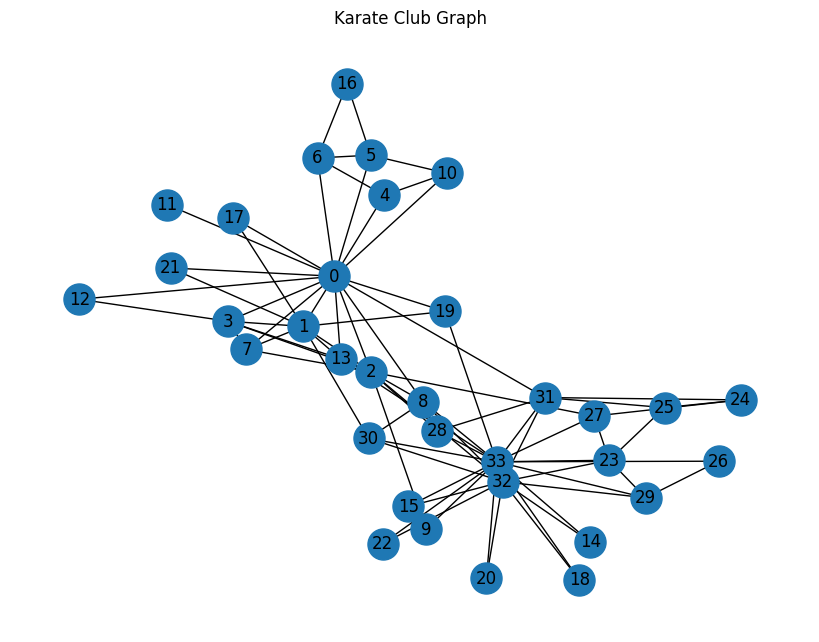

In [4]:

# Visualization
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=500)
plt.title("Karate Club Graph")
plt.show()


## 2. Extended Web Graph of SVNIT

In [5]:

# Basic Web Crawler for SVNIT (limited depth)
base_url = "https://www.svnit.ac.in"
response = requests.get(base_url, timeout=10)
soup = BeautifulSoup(response.text, "html.parser")

links = set()
for link in soup.find_all("a", href=True):
    href = link['href']
    if href.startswith("/"):
        links.add(base_url + href)

# Build Directed Graph
WG = nx.DiGraph()
for l in links:
    WG.add_edge(base_url, l)

# Apply HITS
whubs, wauth = nx.hits(WG, max_iter=1000, normalized=True)

print("Highest Hub:", max(whubs, key=whubs.get))
print("Highest Authority:", max(wauth, key=wauth.get))
print("Lowest Hub:", min(whubs, key=whubs.get))
print("Lowest Authority:", min(wauth, key=wauth.get))


Highest Hub: https://www.svnit.ac.in
Highest Authority: https://www.svnit.ac.in//www.svnit.ac.in/Data/Notice/2025/December/Notice - Ban on Single Use Item.pdf
Lowest Hub: https://www.svnit.ac.in//www.svnit.ac.in/Data/Notice/2025/December/Notice - Ban on Single Use Item.pdf
Lowest Authority: https://www.svnit.ac.in


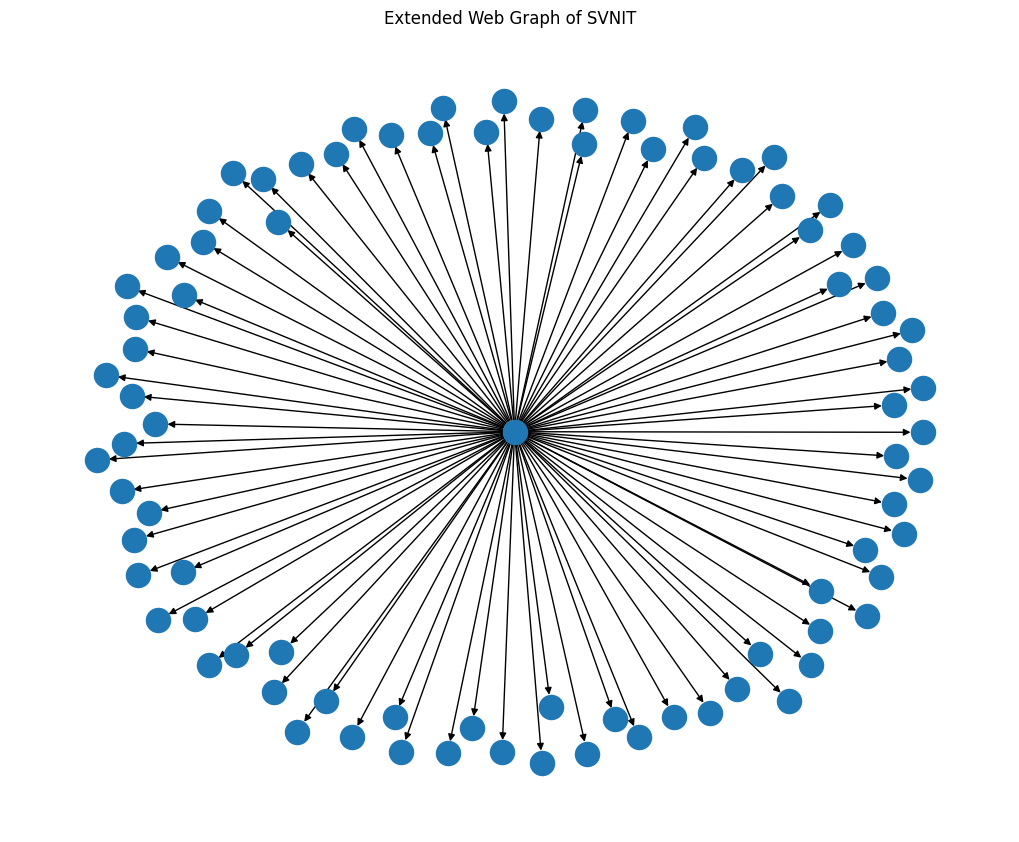

In [6]:

# Visualization of SVNIT Web Graph
plt.figure(figsize=(10,8))
pos = nx.spring_layout(WG)
nx.draw(WG, pos, node_size=300, with_labels=False)
plt.title("Extended Web Graph of SVNIT")
plt.show()



## Observations
- Nodes with high hub scores point to many important pages.
- Nodes with high authority scores are referenced by many hubs.
- SVNIT homepage acts as a major hub.
